    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 8: Implement a program which, given (a) an (even or odd numbered) imageID or an image file name, 
    (b) a user selected latent semantics, and (c) positive integer k, identifies and 
    lists k most likely matching labels, along with their scores, under the selected latent space.

In [8]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

LATENT_SEMANTICS = input(
"""
Provide a latent semantic that was generated using tasks 3 to 6.
For eg:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_svd".
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

K = int(input("Enter K, the K most likely labels to find under the latent space."))

Files already downloaded and verified
Input image:  2501


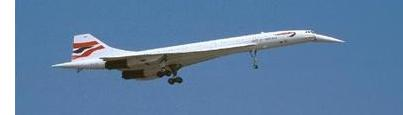

In [9]:
# Find the k most likely for a given query image for the given latent semantics.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [10]:
# Load corresponding feature space.

LATENT_SPACE = LATENT_SEMANTICS.split('_')[0]

FEATURE_SPACE = LATENT_SEMANTICS.split('_')[1]

from utils.database_utils import retrieve
feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

# Load corresponding feature reducer.

reducer = retrieve(f'{LATENT_SEMANTICS}_reducer.pt')

In [11]:
if FEATURE_SPACE == 'color':
    from feature_models.color_moments import ColorMomentsExtractor

    vector = ColorMomentsExtractor(image).get_color_vector()

elif FEATURE_SPACE == 'hog':
    from feature_models.hog import HOGExtractor

    vector = HOGExtractor(image).get_hog_vector()

else:
    # ResNet feature model.
    from feature_models.resnet import ResNetExtractor
    resnet = ResNetExtractor(image)

    if FEATURE_SPACE == 'avgpool':
        vector = resnet.get_avgpool_vector()

    elif FEATURE_SPACE == 'layer3':
        vector = resnet.get_layer3_vector()

    elif FEATURE_SPACE == 'fc':
        vector = resnet.get_fc_vector()
    else:
        # resnet_output feature space.
        vector = resnet.get_output_vector()

In [12]:
from utils.dataset_utils import initialize_dataset
all_labels = initialize_dataset().categories

Files already downloaded and verified


In [13]:
if LATENT_SPACE == 'LS1' or LATENT_SPACE == 'LS2':

    # Generate feature space latent semantics using reducer.

    from utils.vector_utils import get_latent_feature_vectors
    latent_feature_vectors = get_latent_feature_vectors(feature_vectors, reducer)

    # Reduce query vector using reducer to latent space.

    # Interface for reducer is Dict(IMG_ID -> (Label, Vector)), it drops everything but the vector.
    latent_vector = reducer.reduce_features({"QUERY": ("UNKNOWN", vector)})[0]

    from utils.vector_utils import get_representative_vectors_for_labels
    rep_label_latent_vectors = get_representative_vectors_for_labels(latent_feature_vectors, all_labels, K=5)

    # Convert representative label vectors to feature vectors for usage with distance utils.
    # We take care not to use the key of this dictionary as IMG_ID.

    from utils.vector_utils import rep_label_vectors_to_feature_vectors
    rep_latent_feature_vectors = rep_label_vectors_to_feature_vectors(rep_label_latent_vectors)

    from utils.distance_utils import get_distance_fn, top_k_unique_label_distance_ranker
    distances = top_k_unique_label_distance_ranker(K, latent_vector, rep_latent_feature_vectors, get_distance_fn(FEATURE_SPACE))

elif LATENT_SPACE == 'LS3':

    # To utilize label-weight semantics, we first need to compute the image-label similarity vector using the original feature
    # space. We can then reduce this vector to the latent semantics, and then find the most similar labels using the latent space.

    label_feature_vectors = retrieve(f'label_label_{FEATURE_SPACE}.pt')

    from utils.vector_utils import get_latent_feature_vectors
    latent_feature_vectors = get_latent_feature_vectors(label_feature_vectors, reducer)

    rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

    from utils.vector_utils import get_image_label_similarity_vector

    img_label_vector = get_image_label_similarity_vector(vector, rep_label_vectors, all_labels)

    # Interface for reducer is Dict(IMG_ID -> (Label, Vector)), it drops everything but the vector.
    latent_vector = reducer.reduce_features({"QUERY": ("UNKNOWN", img_label_vector)})[0]

    from utils.distance_utils import top_k_distance_ranker, get_distance_fn
    distances = top_k_distance_ranker(K, latent_vector, latent_feature_vectors, get_distance_fn(FEATURE_SPACE))

else:
    # LS4.

    from utils.database_utils import compressed_retrieve
    image_feature_vectors = compressed_retrieve(f'img_img_{FEATURE_SPACE}.pt')

    from utils.vector_utils import get_latent_feature_vectors
    latent_feature_vectors = get_latent_feature_vectors(image_feature_vectors, reducer)

    from utils.vector_utils import get_image_image_similarity_vector
    image_feature_vector = get_image_image_similarity_vector(vector, feature_vectors)

    # Interface for reducer is Dict(IMG_ID -> (Label, Vector)), it drops everything but the vector.
    latent_vector = reducer.reduce_features({"QUERY": ("UNKNOWN", image_feature_vector)})[0]

    from utils.vector_utils import get_representative_vectors_for_labels
    rep_label_latent_vectors = get_representative_vectors_for_labels(latent_feature_vectors, all_labels, K=5)

    # Convert representative label vectors to feature vectors for usage with distance utils.
    # We take care not to use the key of this dictionary as IMG_ID.

    from utils.vector_utils import rep_label_vectors_to_feature_vectors
    rep_latent_feature_vectors = rep_label_vectors_to_feature_vectors(rep_label_latent_vectors)

    from utils.distance_utils import get_distance_fn, top_k_unique_label_distance_ranker
    distances = top_k_unique_label_distance_ranker(K, latent_vector, rep_latent_feature_vectors, get_distance_fn(FEATURE_SPACE))

In [14]:
print("\nK =", K, " most similar labels by ", LATENT_SEMANTICS, " semantics using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(len(distances)):
    distance, dummy_img_id, label = distances[i]

    print(str(i + 1) + ".", "\tLabel: \t", label, "\t\tDistance: ", distance)


K = 5  most similar labels by  LS2_fc_cpd  semantics using distance:  cosine
1. 	Label: 	 airplanes 		Distance:  0.002386645014634703
2. 	Label: 	 helicopter 		Distance:  0.035935526518248495
3. 	Label: 	 pyramid 		Distance:  0.04201225964248023
4. 	Label: 	 minaret 		Distance:  0.06121369593627202
5. 	Label: 	 ketch 		Distance:  0.0797926029306929
